---
---
---
<a name="FSDP2"></a>
## B) Make `QLoRA` work with `FSDP2` [Difficulty: Medium to Hard] [Max points: 10]

1. Goal: Write a single Python script to finetune Llama 3.1 8B on 2x or more GPUs with FSDP2.

2. You must showcase this working in a free **Kaggle notebook with 2 x Tesla T4 GPUs**.

3. Pipeline parallelism is also fine, but must utilize [`zero bubble scheduling`](https://pytorch.org/docs/stable/distributed.pipelining.html#torch.distributed.pipelining.schedules.ScheduleInterleavedZeroBubble) somehow.

4. Can use a pre-quantized 4bit BnB safetensor file from [Unsloth's HF page](https://huggingface.co/unsloth) or a full 16bit one, but must do QLoRA.

5. Can use `accelerate` but must be FSDP2 or related - you can investigate https://github.com/huggingface/accelerate/pull/3394, Torch Titan, other repos etc.

6. Must be fully `transformers` compatible - so we must use `TrainingArguments` and `Trainer`, or `TRL` related classes.

7. The loss must be equivalent to single GPU training.

8. You must enable all features in FSDP2 - ie showcase offloading, checkpointing, mixed precision training etc.

9. You can use `nf4` from `torch AO`, but best from `bitsandbytes`.

10. Finally showcase everything working in a free Kaggle 2x Tesla T4 notebook.

## Marking Criteria for B) Max points = 10
```python
if attemped_B:
    B_score = 0
    if FSDP2_works_with_QLoRA:
        if torch_compile_works: B_score += 5
        else: B_score += 3
        if uses_part_A_and_single_kernel_and_faster: B_score += 3
        elif uses_torchAO:
            if torchAO_slower_than_BnB: B_score -= 3
    elif TP_or_PP_with_QLoRA:
        if zero_bubble: B_score += 3
        else: B_score += 2
    elif FSDP1_works_with_QLoRA:
        B_score += 1
    if kaggle_notebook_2_tesla_t4_example:
        B_score += 2
    else:
        B_score = 0
    final_score += B_score
else:
    final_score -= 2
```

In [1]:
# %%capture

# !pip install unsloth

In [2]:
import torch

torch.__version__

'2.6.0+cu126'

In [3]:
# Helpful functions used through the entire notebook
import torch
import torch.nn as nn
from transformers import set_seed
import time
import inspect
import os

major_version, minor_version = torch.cuda.get_device_capability()
HAS_BFLOAT16 = major_version >= 8
from inspect import currentframe as _C, getframeinfo

_F = lambda c: getframeinfo(c).lineno  # Gets line number
WARN = lambda x: print(f"\033[31m{x}\033[0m")  # Red colored warnings


# https://stackoverflow.com/questions/18425225/getting-the-name-of-a-variable-as-a-string
def NAME(var):
    callers_local_vars = inspect.currentframe().f_back.f_locals.items()
    names = [var_name for var_name, var_val in callers_local_vars if var_val is var]
    return names[0] if len(names) != 0 else ""


def assert_same(x, y, line, dtype):
    assert x.dtype == dtype
    try:
        torch.testing.assert_close(x, y, check_stride=True)
    except Exception as error:
        raise RuntimeError(
            f"Failed allclose at line [{line}]: {NAME(x)}, {NAME(y)}\n{str(error)}"
        )


os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

In [4]:
# HELPFUL functions to undo Unsloth patches:
import sys


def remove_patched_module(package_name):
    modules_to_delete = [
        name
        for name in sys.modules
        if name == package_name or name.startswith(package_name + ".")
    ]
    for name in modules_to_delete:
        del sys.modules[name]


remove_patched_module("trl")
remove_patched_module("transformers")
remove_patched_module("peft")
remove_patched_module("bitsandbytes")

In [5]:
import os

os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = (
    "expandable_segments:True," "roundup_power2_divisions:[32:256,64:128,256:64,>:32]"
)

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import get_peft_model, LoraConfig, TaskType

max_seq_length = 2048
torch.set_default_dtype(torch.float16)
model_name = "unsloth/meta-Llama-3.1-8B-Instruct-bnb-4bit"
dtype = torch.float16
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=dtype,
)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    # device_map="auto",
    attn_implementation="sdpa",
    quantization_config=bnb_config,
)
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.padding_side = "right"

lora_config = LoraConfig(
    r=64,
    lora_alpha=128,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_dropout=0,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

# Get LoRA and setup model
model = get_peft_model(model, lora_config)
with torch.no_grad():
    for name, param in model.named_parameters():
        if ".lora_A." in name or ".lora_B." in name:
            param.requires_grad_(True)
        else:
            param.requires_grad_(False)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()

# Get dataset
from datasets import load_dataset
from trl import SFTTrainer, SFTConfig

url = "https://huggingface.co/datasets/laion/OIG/resolve/main/unified_chip2.jsonl"
dataset = load_dataset("json", data_files={"train": url}, split="train[:10%]")

/opt/conda/lib/python3.12/site-packages/transformers/quantizers/auto.py:212: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)
`low_cpu_mem_usage` was None, now default to True since model is quantized.
`low_cpu_mem_usage` was None, now default to True since model is quantized.


Note  that the model defined here has a different lora config from the models in the other parts (`r=64`, `lora_alpha=128` vs `r=32`, `lora_alpha=64` in the others)

In [6]:
# trainer = SFTTrainer(
#     model=model,
#     train_dataset=dataset,
#     processing_class=tokenizer,
#     args=SFTConfig(
#         per_device_train_batch_size=1,
#         gradient_accumulation_steps=2,
#         warmup_steps=1,
#         max_steps=10,
#         logging_steps=1,
#         output_dir="outputs",
#         seed=3407,
#         max_seq_length=max_seq_length,
#         fp16=model.get_input_embeddings().weight.dtype == torch.float16,
#         bf16=model.get_input_embeddings().weight.dtype == torch.bfloat16,
#         report_to="none",  # For W&B
#         dataset_num_proc=4,
#     ),
# )

# trainer.train()


# train_history = trainer.state.log_history
# original_losses = []
# original_steps = []

# for log in train_history:
#     if "loss" in log:
#         original_losses.append(log["loss"])
#         original_steps.append(log["step"])



In [7]:
original_losses, original_steps = [1.4065, 2.1792, 2.0003, 3.2503, 1.9516, 2.7509, 1.9253, 1.4287, 1.884, 2.0887], list(range(1, 10 + 1))

In [8]:
# del model
# import gc

# gc.collect()
# torch.cuda.empty_cache()

# model = AutoModelForCausalLM.from_pretrained(
#     model_name,
#     # device_map="auto",
#     attn_implementation="sdpa",
#     quantization_config=bnb_config,
# )

# # Get LoRA and setup model
# model = get_peft_model(model, lora_config)
# with torch.no_grad():
#     for name, param in model.named_parameters():
#         if ".lora_A." in name or ".lora_B." in name:
#             param.requires_grad_(True)
#         else:
#             param.requires_grad_(False)
# model.gradient_checkpointing_enable()
# model.enable_input_require_grads()

Overview:
- We use our part C and A solutions as a base.
- To enable mixed precision policy with `Linear4bitCompilable`, we cast the weights to match the dtype of the input (more relevant on my machine where both bf16 and fp16 are available and `Linear4bit` uses bf16 by default)
- To enable cpu offloading, we add `cpu:gloo` as a backend
- To allow torch compile to trace our sharded `Linear4bitCompilable`, we add a try-except to its attempt to match the subgraph as a weight-only quantized op (which would otherwise fail because the traced subgraph does not have `scales` with `meta`)
- We help the trainer checkpoint/save the model by patching peft's `save_pretrained` to include localizing all `Dtensor` tensors before saving
- `Linear4bit` (the base module and child module of lora), is sharded before its parent module, lora. This is in-line with the bottom up sharding approach of FSDP2, and allows us to disable sharding after forward for `Linear4bit` since its not necessary (it's frozen).

In [9]:
torch_compile_options = {
    "epilogue_fusion": True,
    "max_autotune": True,
    "shape_padding": True,
    "trace.enabled": True,
    "triton.cudagraphs": False,
}

# Borrow from C: we want to find and eliminate graph breaks in torch.compile
import os

os.environ["TORCHDYNAMO_VERBOSE"] = "1"
os.environ["TORCHINDUCTOR_FORCE_DISABLE_CACHES"] = "1"
os.environ["TORCHINDUCTOR_COMPILE_THREADS"] = "1"

import logging

torch._inductor.config.debug = True
torch._logging.set_logs(
    dynamo=logging.WARN,
    inductor=logging.WARN,
    graph_breaks=True,
    # recompiles=True,
    # recompiles_verbose=True,
    # compiled_autograd_verbose=True,
)
torch._dynamo.config.verbose = False
torch._dynamo.config.suppress_errors = False

In [10]:
import socket

def find_free_port():
    """Finds an available port on localhost."""
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind(("", 0))  # Bind to "" (all interfaces) and port 0 (ephemeral)
        port = s.getsockname()[1] # Get the assigned port
    return str(port)

find_free_port()

'38817'

In [11]:
from torch.distributed import DeviceMesh, init_process_group
from datetime import timedelta

# Set required environment variables
os.environ["RANK"] = "0"  # Set the rank of the current process
os.environ["WORLD_SIZE"] = str(torch.cuda.device_count())  # Set the total number of processes
os.environ["MASTER_ADDR"] = "localhost"  # Set the master address
os.environ["MASTER_PORT"] = find_free_port()  # Set the master port

# init the process group for not just cuda (nccl) but also the cpu (because we want to use CPU offload)
# https://github.com/pytorch/pytorch/issues/148532
# https://github.com/pytorch/torchtitan/blob/aed946c8ef36e6b3d424d6bfd25fff5ca4a97e02/torchtitan/distributed/utils.py#L181-L182
init_process_group("cuda:nccl,cpu:gloo", timeout=timedelta(seconds=45))

# 1d mesh
mesh = DeviceMesh(device_type="cuda", mesh=torch.arange(int(os.environ["WORLD_SIZE"])))

In [12]:
# similarly, let's set configs for FSDP2
from torch.distributed.fsdp import CPUOffloadPolicy, MixedPrecisionPolicy, fully_shard

# we'll be using cpu offloading and mixed precision training
# torch.set_num_threads(os.cpu_count() // torch.cuda.device_count())

# This mp policy is already enough to mess with sharding Linear4Bit
mp_policy = MixedPrecisionPolicy(param_dtype=torch.float16, reduce_dtype=torch.float16, cast_forward_inputs=True)


Plug in our kernel from A:

In [13]:
import triton 
import triton.language as tl


@triton.jit
def gather_nf4_code(code_index, code_ptr):
    """In newer versions of triton, we attempt to use gather here on the code values.
        But since that's not available, we use this instead.
    """
    return tl.load(code_ptr + code_index, mask=code_index<16, eviction_policy="evict_last")


@triton.autotune(
    configs=[
        # triton.Config({'BLOCK_SIZE': 32}),
        # triton.Config({'BLOCK_SIZE': 64}),
        triton.Config({'BLOCK_SIZE': 128}),
        # triton.Config({'BLOCK_SIZE': 256}),
    ],
    key=['total_elements'],
)
@triton.jit()
def _your_dequantize_nf4_kernel(
    weight_ptr,  # [uint8]  Quantized weights, 1 byte => 2 NF4 elements
    absmax_ptr,  # [int]  One int "index" per element
    absmax2_ptr,  # [float]  One absmax2 per block
    code_ptr,  # [float]  NF4 code lookup
    code2_ptr,  # [float]  Absmax code lookup
    offset_ptr,  # [float]  Offset to add after absmax is decoded
    out_ptr,  # [float]  Final dequantized output
    weight_blocksize: tl.constexpr,  # [int]   Number of elements in a weight block
    absmax_blocksize: tl.constexpr, # [int]   Number of elements in a absmax block
    total_elements,  # [int]   Number of actual float elements to reconstruct
    BLOCK_SIZE: tl.constexpr,
):
    # context; we adopt the pov of a quantized byte, which corresponds to 2 elems
    pid = tl.program_id(0)
    start = pid * BLOCK_SIZE
    index = start + tl.arange(0, BLOCK_SIZE)

    offset = tl.load(offset_ptr, eviction_policy="evict_last")

    # the block index of the byte
    # weight_block_index = index // (weight_blocksize // 2) # naive approach
    # now we end up with a vector like (0, 0, ... 0, 0, 1, 1, ...)
    # we can shrink this by applying a stride of weight_blocksize // 2 so that our vector looks like (0, 1, 2, ...)
    weight_block_index = start // (weight_blocksize // 2) + tl.arange(0, BLOCK_SIZE // (weight_blocksize // 2))
    absmax_block_index = weight_block_index // absmax_blocksize # the block index of the absmax

    # mask calculations
    byte_index_mask = index < (total_elements // 2)
    weight_block_mask = weight_block_index < (total_elements // weight_blocksize) 
    abs_block_mask = absmax_block_index < (total_elements // weight_blocksize // absmax_blocksize)

    # compute absmax for the block these weights belong to:
    absmax1_code = tl.load(absmax_ptr + weight_block_index, mask=weight_block_mask, eviction_policy="evict_last")
    absmax1_code = absmax1_code.to(tl.int16) # this is necessary
    
    # reading values from code is likely a very slow process due to lack of contiguity
    absmax1_val = tl.load(code2_ptr + absmax1_code, mask=(absmax1_code < 256))
    absmax2_val = tl.load(absmax2_ptr + absmax_block_index, mask=abs_block_mask, eviction_policy="evict_last")
    
    absmax = tl.fma(absmax1_val, absmax2_val, offset)

    # lookup each weight bit
    byte = tl.load(weight_ptr + index, mask=byte_index_mask, eviction_policy="evict_first")

    code_index2 = byte & 0x0F  # Lower 4 bits
    code_index1 = (byte >> 4) & 0x0F  # Upper 4 bits

    code_index_range = tl.arange(0, 16) # 16 possible values
    _ = tl.load(code_ptr + code_index_range, eviction_policy="evict_last") # pull code contiguously into cache

    # interleaving the values here, prior to matmul, causes a slight decrease in average perf on T4 (poorer lower bound)
    # weight = dequantize_nf4_code(tl.interleave(code_index1, code_index2)).reshape(BLOCK_SIZE // (weight_blocksize // 2), weight_blocksize) * absmax[:, None]

    # Dequantize both 4-bit values
    weight1 = gather_nf4_code(code_index1, code_ptr).reshape(BLOCK_SIZE // (weight_blocksize // 2), weight_blocksize // 2) * absmax[:, None]
    weight2 = gather_nf4_code(code_index2, code_ptr).reshape(BLOCK_SIZE // (weight_blocksize // 2), weight_blocksize // 2) * absmax[:, None]

    # combine to prevent a non-contiguous write because of writing to even/odd indexes
    weight_index = start * 2 + tl.arange(0, BLOCK_SIZE * 2)
    weight = tl.interleave(weight1, weight2)
    tl.store(out_ptr + weight_index, tl.ravel(weight), mask=weight_index < total_elements)


NF4_WEIGHT_BLOCKSIZE = 64
NF4_ABSMAX_BLOCKSIZE = 256
# taken from bitsandbytes get_4bit_type to ensure we use the same values
# https://github.com/bitsandbytes-foundation/bitsandbytes/blob/86b6c37a8ad448230cedb60753f63150b603a112/bitsandbytes/functional.py#L1075
NF4_CODE_VALUES = torch.tensor([
            -1.0,
            -0.6961928009986877,
            -0.5250730514526367,
            -0.39491748809814453,
            -0.28444138169288635,
            -0.18477343022823334,
            -0.09105003625154495,
            0.0,
            0.07958029955625534,
            0.16093020141124725,
            0.24611230194568634,
            0.33791524171829224,
            0.44070982933044434,
            0.5626170039176941,
            0.7229568362236023,
            1.0,
        ], 
        dtype=torch.float32,
        device="cuda"
        )


def triton_dequantize_nf4(weight, quant_state):
    absmax = quant_state.absmax
    shape = quant_state.shape
    dtype = quant_state.dtype
    offset = quant_state.offset
    state2 = quant_state.state2
    absmax2 = state2.absmax
    code2 = state2.code

    out = torch.empty(shape, dtype=dtype, device="cuda")
    # cdiv: (x + y - 1) // y
    weight_grid = lambda meta: ((out.numel() // 2 + meta["BLOCK_SIZE"] -1) // meta["BLOCK_SIZE"], )

    _your_dequantize_nf4_kernel[weight_grid](
        weight,
        absmax,
        absmax2,
        NF4_CODE_VALUES,
        code2,
        offset,
        out,
        weight_blocksize=NF4_WEIGHT_BLOCKSIZE,
        absmax_blocksize=NF4_ABSMAX_BLOCKSIZE,
        total_elements=out.numel(),
    )

    # the fact that it could need a transpose is already handled, no need to replicate that
    return out

In [14]:
class Linear4bitCompilable(nn.Module):
    def __init__(self, bnb_linear):
        super().__init__()
        # Copy over quantized weight and metadata from the bitsandbytes layer
        self.in_features = bnb_linear.in_features
        self.out_features = bnb_linear.out_features
        self.quant_type = bnb_linear.weight.quant_type
        self.blocksize = bnb_linear.weight.blocksize
        self.weight = bnb_linear.weight.data  # don't trace param 4 bit, access its vars here
        self.quant_state = bnb_linear.weight.quant_state
        self.bias = bnb_linear.bias
        
        # Freeze weight and metadata as buffers (no grad needed)
        self.weight.requires_grad_(False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # mp policy means that quant_state.dtype may not match dtype expected by x
        # two different ways to handle the dequantization & typing
        # 1. dequantize in the dtype defined by quant state, then cast to x.dtype
        # 2. dequantize in the dtype of x
        # we're going with (1), which altho less performant is less complicated

        # Use the triton kernel for dequantization
        if self.quant_type == "nf4":
            # Dequantize the weights using the triton kernel
            # cast the weights to match the type of the input
            W = triton_dequantize_nf4(self.weight, self.quant_state).to(x.dtype)
        else:
            # For other quantization types (like fp4), we would need a different implementation
            raise NotImplementedError(f"Quantization type {self.quant_type} not supported yet")
            
        # Compute linear output: x @ W^T + bias
        out = torch.matmul(x, W.t())
        if self.bias is not None:
            out = out + self.bias.to(x.dtype)
        return out


In [15]:
modules_to_replace = []
for name, module in model.named_modules():
    module_type = str(type(module))
    # we'll handle lora modules later
    if "lora" in module_type.lower():
        continue
    if "bnb" in module_type or "bitsandbytes" in module_type:
        # print(name, type(module))
        modules_to_replace.append(name)

modules_to_replace[-2:]

['base_model.model.model.layers.31.mlp.up_proj.base_layer',
 'base_model.model.model.layers.31.mlp.down_proj.base_layer']

Test fully sharding the `Linear4bitCompilable` module

In [16]:
TARGET_BNB_MODULE_NAME = "base_model.model.model.layers.7.mlp.gate_proj.base_layer"
module = model.get_submodule(TARGET_BNB_MODULE_NAME)

INPUT_SHAPE = (4, 128, module.weight.quant_state.shape[-1]) #  (Batch, SeqLen, HiddenDim), matching in features

module

Linear4bit(in_features=4096, out_features=14336, bias=False)

In [17]:
TEST_DTYPE = torch.float16 if not HAS_BFLOAT16 else torch.bfloat16
DEVICE = "cuda"

# --- The Test Function ---
def test_linear4bit_patch_equivalence(original_module, input_shape, dtype, device):
    print(f"--- Testing Module: {original_module} ---")
    print(f"Input shape: {input_shape}, dtype: {dtype}, Device: {device}")

    original_module.to(device)
    print(original_module.weight.quant_state.dtype)

    # 2. Create Regular and Compiled versions
    # Ensure weights/state are copied *before* moving original to device if needed
    patch_eager = Linear4bitCompilable(original_module).to(device)
    patch_compiled = Linear4bitCompilable(original_module).to(device)

    # Explicitly compile the forward method of patch_compiled *after* instantiation
    print("Compiling Linear4bitCompilable forward method...")
    try:
        # We compile the instance's method, not the class method directly
        patch_compiled.forward = torch.compile(
            patch_compiled.forward,
            fullgraph=True,
            dynamic=True,
            options=torch_compile_options
        )
        print("Compilation successful (initial).")
    except Exception as e:
        print(f"ERROR: torch.compile failed during setup: {e}")
        return

    # 3. Create the sharded version by sharding the already compiled model
    print("Setting up sharded -> compiled version...")
    # Create a clone of the compiled module that we'll shard
    patch_to_shard = Linear4bitCompilable(original_module).to(device)
    
    
    # Now shard the compiled module
    try:
        # Shard the compiled module
        patch_sharded_compiled = fully_shard(
            patch_to_shard,
            mesh=mesh,
            reshard_after_forward=False,
            offload_policy=CPUOffloadPolicy(pin_memory=False),
            mp_policy=MixedPrecisionPolicy(param_dtype=dtype, reduce_dtype=dtype, cast_forward_inputs=True)
        )
        print("Sharding successful on module.")
        patch_sharded_compiled.forward = torch.compile(
            patch_sharded_compiled.forward,
            fullgraph=False,
            dynamic=True,
            options=torch_compile_options
        )
        print("Compilation for sharded model successful.")
        
    except Exception as e:
        print(f"ERROR: FSDP fully_shard failed during setup: {e}")
        patch_sharded_compiled = None

    # 4. Create Input Tensor
    x_input = torch.randn(input_shape, dtype=dtype, device=device, requires_grad=True)
    x_input_clone1 = x_input.clone().detach().requires_grad_(True)
    x_input_clone2 = x_input.clone().detach().requires_grad_(True)
    x_input_clone3 = x_input.clone().detach().requires_grad_(True)

    # --- Forward Pass ---
    print("\n--- Running Forward Pass ---")

    # do this forward pass with gradient tracking (will do backward later)
    out_patch_eager = patch_eager(x_input_clone1)
    print("Patched Eager forward: Done")
    out_patch_compiled = patch_compiled(x_input_clone2)
    print("Patched Compiled forward: Done")
    out_patch_sharded = patch_sharded_compiled(x_input_clone3)
    print("Patched Compiled+Sharded forward: Done")

    # --- Forward Pass Assertions ---
    print("\n--- Forward Pass Assertions ---")
    try:
        print("Comparing: Patched Eager vs Patched Compiled")
        assert_same(out_patch_eager, out_patch_compiled, 0, dtype)
        print("Comparing: Patched Compiled vs Patched Compiled+Sharded")
        assert_same(out_patch_compiled, out_patch_sharded, 1, dtype)
        print("Forward assertions PASSED.")
    except Exception as e:
        print(f"\n!!! ERROR during forward pass assertions: {e}")
        return # Stop if forward outputs don't match

    # --- Backward Pass ---
    print("\n--- Running Backward Pass ---")
    # Use a simple reduction for backward
    loss_patch_eager = out_patch_eager.sum()
    loss_patch_compiled = out_patch_compiled.sum()
    loss_patch_sharded = out_patch_sharded.sum()

    print("Backward: Patched Eager...")
    loss_patch_eager.backward()
    print("Backward: Patched Compiled...")
    loss_patch_compiled.backward()
    print("Backward: Patched Compiled+Sharded...")
    loss_patch_sharded.backward()
    print("Backward passes Done.")

    # --- Backward Pass Assertions (Input Gradients) ---
    print("\n--- Backward Pass Assertions (Input Gradients) ---")
    try:
        grad_patch_eager = x_input_clone1.grad
        grad_patch_compiled = x_input_clone2.grad
        grad_patch_sharded = x_input_clone3.grad

        print("Comparing Grads: Patched Eager vs Patched Compiled")
        assert_same(grad_patch_eager, grad_patch_compiled, 0, dtype)

        print("Comparing Grads: Patched Compiled vs Patched Compiled+Sharded")
        assert_same(grad_patch_compiled, grad_patch_sharded, 1, dtype)

        print("Backward assertions PASSED.")
    except Exception as e:
        print(f"\n!!! ERROR during backward pass assertions: {e}")
        return

    print(f"\n--- Test for {original_module} Completed Successfully ---")


test_linear4bit_patch_equivalence(
    module,
    INPUT_SHAPE,
    TEST_DTYPE,
    DEVICE
)


--- Testing Module: Linear4bit(in_features=4096, out_features=14336, bias=False) ---
Input shape: (4, 128, 4096), dtype: torch.bfloat16, Device: cuda
torch.bfloat16
Compiling Linear4bitCompilable forward method...
Compilation successful (initial).
Setting up sharded -> compiled version...
Sharding successful on module.
Compilation for sharded model successful.

--- Running Forward Pass ---
Patched Eager forward: Done


[rank0]:W0415 22:02:18.628000 61715 site-packages/torch/_inductor/debug.py:435] [0/0] model__0_forward_1 debug trace: /workspaces/unsloth-ai-feb2025/torch_compile_debug/run_2025_04_15_22_02_17_700430-pid_61715/torchinductor/model__0_forward_1.0
[rank0]:W0415 22:02:18.795000 61715 site-packages/torch/_inductor/debug.py:435] [0/0] model__0_backward_2 debug trace: /workspaces/unsloth-ai-feb2025/torch_compile_debug/run_2025_04_15_22_02_17_700430-pid_61715/torchinductor/model__0_backward_2.1


Patched Compiled forward: Done


[rank0]:W0415 22:02:19.271000 61715 site-packages/torch/_inductor/debug.py:435] [0/1] model__1_forward_4 debug trace: /workspaces/unsloth-ai-feb2025/torch_compile_debug/run_2025_04_15_22_02_17_700430-pid_61715/torchinductor/model__1_forward_4.2
[rank0]:W0415 22:02:19.460000 61715 site-packages/torch/_inductor/debug.py:435] [0/1] model__1_backward_5 debug trace: /workspaces/unsloth-ai-feb2025/torch_compile_debug/run_2025_04_15_22_02_17_700430-pid_61715/torchinductor/model__1_backward_5.3


Patched Compiled+Sharded forward: Done

--- Forward Pass Assertions ---
Comparing: Patched Eager vs Patched Compiled
Comparing: Patched Compiled vs Patched Compiled+Sharded
Forward assertions PASSED.

--- Running Backward Pass ---
Backward: Patched Eager...
Backward: Patched Compiled...
Backward: Patched Compiled+Sharded...
Backward passes Done.

--- Backward Pass Assertions (Input Gradients) ---
Comparing Grads: Patched Eager vs Patched Compiled
Comparing Grads: Patched Compiled vs Patched Compiled+Sharded
Backward assertions PASSED.

--- Test for Linear4bit(in_features=4096, out_features=14336, bias=False) Completed Successfully ---


In [18]:
# patch modules for torch compile
# fully shard is an in-place op. but we'll do it later at all once
for name in modules_to_replace:
    module = model.get_submodule(name)
    # create a new patched module from the old one
    new_module = Linear4bitCompilable(module)
    # shard before compiling
    fully_shard(new_module,
        reshard_after_forward=False,
        mp_policy=mp_policy,
        mesh=mesh,
        offload_policy=CPUOffloadPolicy(pin_memory=False)
    )
    new_module.forward = torch.compile(
        new_module.forward,
        fullgraph=False, dynamic=True, options=torch_compile_options
    )
    # Find the direct parent module
    parts = name.split('.')
    parent = model
    for i in range(len(parts) - 1):
        parent = parent.get_submodule(parts[i])

    module_name = parts[-1] # The attribute name within the parent
    setattr(parent, module_name, new_module)


As noted in FSDP2 docs, `fully_shard` should be called bottom up and generally not on top level modules.
>  Calling fully_shard() on module constructs one group that includes the parameters in module.parameters() except those already assigned to a group from an earlier call on a submodule. This means that fully_shard() should be called bottom-up on your model. Each group’s parameters are all-gathered in one collective, and its gradients are reduce-scattered in one collective. Partitioning the model into multiple groups (“layer by layer”) allows for peak memory savings and communication/computation overlap. Users generally should not call fully_shard() only on the topmost root module.

In following this, we next fully shard the Lora module, which needs to be handled a bit different from the Linear4bit "base module" which we just patched out. This module actually has gradients!

In [19]:
for name, module in model.named_modules():
    module_type = str(type(module))

    if "peft.tuners.lora.bnb.Linear4bit".lower() in module_type.lower():
        # fully shard these modules
        fully_shard(module,
            reshard_after_forward=True,
            mp_policy=mp_policy,
            mesh=mesh,
            offload_policy=CPUOffloadPolicy(pin_memory=False)
        )

Compile the top level modules, as per part C (prior to flex attention patch)

In [20]:
from typing import Optional, Tuple
from transformers.integrations.sdpa_attention import repeat_kv

def patched_sdpa_attention_forward(
    module: torch.nn.Module,
    query: torch.Tensor,
    key: torch.Tensor,
    value: torch.Tensor,
    attention_mask: Optional[torch.Tensor],
    dropout: float = 0.0,
    scaling: Optional[float] = None,
    is_causal: Optional[bool] = None,
    **kwargs,
) -> Tuple[torch.Tensor, None]:

    # stole sdpa implementation from source
    if hasattr(module, "num_key_value_groups"):
        key = repeat_kv(key, module.num_key_value_groups)
        value = repeat_kv(value, module.num_key_value_groups)

    causal_mask = attention_mask
    if attention_mask is not None:
        causal_mask = causal_mask[:, :, :, : key.shape[-2]]

    query = query.contiguous()
    key = key.contiguous()
    value = value.contiguous()

    # we can just set is_casual to true since we're training
    attn_output = torch.nn.functional.scaled_dot_product_attention(
        query,
        key,
        value,
        attn_mask=causal_mask,
        dropout_p=dropout,
        scale=scaling,
        is_causal=True,
    )
    attn_output = attn_output.transpose(1, 2).contiguous()

    return attn_output, None


from transformers.models.llama.modeling_llama import apply_rotary_pos_emb

def patched_llama_attention_forward(
    self,
    hidden_states: torch.Tensor,
    position_embeddings: Tuple[torch.Tensor, torch.Tensor],
    attention_mask: Optional[torch.Tensor],
    past_key_value = None,
    cache_position: Optional[torch.LongTensor] = None,
    **kwargs,
) -> Tuple[torch.Tensor, Optional[torch.Tensor], Optional[Tuple[torch.Tensor]]]:
    input_shape = hidden_states.shape[:-1]
    hidden_shape = (*input_shape, -1, self.head_dim)

    query_states = self.q_proj(hidden_states).view(hidden_shape).transpose(1, 2)
    key_states = self.k_proj(hidden_states).view(hidden_shape).transpose(1, 2)
    value_states = self.v_proj(hidden_states).view(hidden_shape).transpose(1, 2)

    cos, sin = position_embeddings
    query_states, key_states = apply_rotary_pos_emb(query_states, key_states, cos, sin)

    if past_key_value is not None:
        # sin and cos are specific to RoPE models; cache_position needed for the static cache
        cache_kwargs = {"sin": sin, "cos": cos, "cache_position": cache_position}
        key_states, value_states = past_key_value.update(key_states, value_states, self.layer_idx, cache_kwargs)

    attn_output, attn_weights = patched_sdpa_attention_forward(
        self,
        query_states,
        key_states,
        value_states,
        attention_mask,
        dropout=0.0 if not self.training else self.attention_dropout,
        scaling=self.scaling,
        **kwargs,
    )

    attn_output = attn_output.reshape(*input_shape, -1).contiguous()
    attn_output = self.o_proj(attn_output)
    return attn_output, attn_weights


import transformers.models.llama.modeling_llama
transformers.models.llama.modeling_llama.LlamaAttention.forward = patched_llama_attention_forward

torch compile will atempt to bin Linear4bit as a weight-only quantized (WOQ) linear operation, make a check and fail to match.
However this check has expectations on the params of `Linear4bitCompilable`, which will fail. We can choose to modify our implementation or the check. In this case, we change the check (which should honestly have been more flexible)

In [21]:
def patch_is_valid_woq_optimization_pattern():
    def fn(match):
        assert all(k in match.kwargs for k in ("x", "weight", "scales"))
        try:
            x = match.kwargs["x"].meta["val"]
            weight = match.kwargs["weight"].meta["val"]
            scales = match.kwargs["scales"].meta["val"]
            return (
                # For now, we only support woq mm kernels
                # with x.type=bfloat16 and w.type=int8
                x.dtype == torch.bfloat16
                and weight.dtype == torch.int8
                and scales.dtype == torch.bfloat16
                # _weight_int8pack_mm kernel only supports cpu now
                # TODO: add cuda kernel support instead of calling mul+sum
                and x.device.type == "cpu"
                and x.device == weight.device
                and x.device == scales.device
            )
        except AttributeError:
            # match does not conform to expected param structure
            return False

    return fn

import torch._inductor.fx_passes.quantization as inductor_quantization

inductor_quantization._is_valid_woq_optimization_pattern = patch_is_valid_woq_optimization_pattern

We compile the remaining top level modules. Layernorm is also sharded before compiling because it is outside of the "lora tree" that we have already sharded and compiled. This extends our coverage of sharding and compilation to all levels of the model.

In [22]:
module_names = set()
for index, child in model.base_model.model.model.layers.named_children():
    for name, module in child.named_children():
        if any(k in name for k in ["mlp", "self_atten"]):
            module = torch.compile(module, fullgraph=False, dynamic=True, options=torch_compile_options)
            setattr(child, name, module)

        if any(k in name for k in ["layernorm"]):
            fully_shard(module,
                reshard_after_forward=False,
                mp_policy=mp_policy,
                mesh=mesh,
                offload_policy=CPUOffloadPolicy(pin_memory=False)
            )
            module = torch.compile(module, fullgraph=False, dynamic=True, options=torch_compile_options)
            setattr(child, name, module)
            
        
        module_names.add(name)

In [23]:
model.model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096, padding_idx=128004)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): lora.FSDPLinear4bit(
            (base_layer): FSDPLinear4bitCompilable()
            (lora_dropout): ModuleDict(
              (default): Identity()
            )
            (lora_A): ModuleDict(
              (default): Linear(in_features=4096, out_features=64, bias=False)
            )
            (lora_B): ModuleDict(
              (default): Linear(in_features=64, out_features=4096, bias=False)
            )
            (lora_embedding_A): ParameterDict()
            (lora_embedding_B): ParameterDict()
            (lora_magnitude_vector): ModuleDict()
          )
          (k_proj): lora.FSDPLinear4bit(
            (base_layer): FSDPLinear4bitCompilable()
            (lora_dropout): ModuleDict(
              (default): Identity()
            )
            (l

There's probably a better way to do this via some training arguments (but then we might have to disentangle our FSDP wrapping with the trainer's), but the main thing here is that we need to help the trainer/peft save the model.

>File /opt/conda/lib/python3.12/site-packages/peft/peft_model.py:303, in PeftModel.save_pretrained(self, save_directory, safe_serialization, selected_adapters, save_embedding_layers, is_main_process, path_initial_model_for_weight_conversion, **kwargs)
    299 for name, tensor in output_state_dict.items():
    300     # Sometimes in the state_dict we have non-tensor objects.
    301     # e.g. in bitsandbytes we have some `str` objects in the state_dict
    302     if isinstance(tensor, torch.Tensor):
--> 303         ptrs[id_tensor_storage(tensor)].append(name)

...
>RuntimeError: Attempted to access the data pointer on an invalid python storage.

In [24]:
from torch.distributed.tensor import DTensor
import collections
import copy
import os
import warnings
from typing import Any, Optional, Union

from safetensors.torch import save_file as safe_save_file
from peft.utils import (
    SAFETENSORS_WEIGHTS_NAME,
    WEIGHTS_NAME,
    get_peft_model_state_dict,
    id_tensor_storage,
)


def patched_save_pretrained(
    self,
    save_directory: str,
    safe_serialization: bool = True,
    selected_adapters: Optional[list[str]] = None,
    save_embedding_layers: Union[str, bool] = "auto",
    is_main_process: bool = True,
    path_initial_model_for_weight_conversion: Optional[str] = None,
    **kwargs: Any,
) -> None:
    
    if os.path.isfile(save_directory):
        raise ValueError(f"Provided path ({save_directory}) should be a directory, not a file")

    if selected_adapters is None:
        selected_adapters = list(self.peft_config.keys())
    else:
        if any(
            selected_adapter_name not in list(self.peft_config.keys())
            for selected_adapter_name in selected_adapters
        ):
            raise ValueError(
                f"You passed an invalid `selected_adapters` arguments, current supported adapter names are"
                f" {list(self.peft_config.keys())} - got {selected_adapters}."
            )

    def save_mutated_as_lora(peft_config, path_initial_model_for_weight_conversion, output_state_dict, kwargs):
        if peft_config.use_rslora and (peft_config.rank_pattern or peft_config.alpha_pattern):
            msg = (
                "Passing `path_initial_model_for_weight_conversion` to `save_pretrained` is not supported when "
                "using `rank_pattern` or `alpha_pattern` at the same time as `use_rslora=True`."
            )
            raise ValueError(msg)

        if not any(
            str(peft_config.init_lora_weights).lower().startswith(prefix)
            for prefix in ["pissa", "corda", "olora", "true"]
        ):
            warnings.warn(
                "`path_initial_model_for_weight_conversion` only works for converting a PiSSA/CorDA/OLoRA adapter to "
                "a LoRA adapter"
            )
        initial_adapter_name = os.path.basename(path_initial_model_for_weight_conversion)
        try:
            self.load_adapter(
                os.path.dirname(path_initial_model_for_weight_conversion),
                subfolder=initial_adapter_name,
                adapter_name=initial_adapter_name,
            )
            is_pissa = str(self.peft_config[initial_adapter_name].init_lora_weights).lower().startswith("pissa")
            is_corda = str(self.peft_config[initial_adapter_name].init_lora_weights).lower() == "corda"
            is_olora = str(self.peft_config[initial_adapter_name].init_lora_weights).lower() == "olora"
            if is_pissa or is_corda or is_olora:
                raise ValueError(
                    "The `init_lora_weights` parameter of the initial adapter should be set to `True`. "
                    "Otherwise, `self.load_adapter` will subtract the decomposed values again based on the "
                    "residual model."
                )
            output_state_dict = self.base_model.subtract_mutated_init(
                output_state_dict, initial_adapter_name, kwargs
            )
        finally:
            self.delete_adapter(initial_adapter_name)
        return output_state_dict

    if is_main_process:
        os.makedirs(save_directory, exist_ok=True)
        self.create_or_update_model_card(save_directory)

    for adapter_name in selected_adapters:
        peft_config = self.peft_config[adapter_name]
        # save only the trainable weights
        output_state_dict = get_peft_model_state_dict(
            self,
            state_dict=kwargs.get("state_dict", None),
            adapter_name=adapter_name,
            save_embedding_layers=save_embedding_layers,
        )
        output_dir = os.path.join(save_directory, adapter_name) if adapter_name != "default" else save_directory
        os.makedirs(output_dir, exist_ok=True)

        if is_main_process and safe_serialization:

            # we need to localize all DTensors before they can be saved
            for name, tensor in output_state_dict.items():
                if isinstance(tensor, DTensor):
                    # If the tensor is a DTensor, we need to get the underlying tensor
                    tensor = tensor.to_local()
                    if not isinstance(tensor, torch.Tensor):
                        tensor.wait()
                    output_state_dict[name] = tensor

            # Section copied from: https://github.com/huggingface/transformers/blob/main/src/transformers/modeling_utils.py#L2111-L2134
            # Safetensors does not allow tensor aliasing.
            # We're going to remove aliases before saving
            ptrs = collections.defaultdict(list)
            for name, tensor in output_state_dict.items():
                # Sometimes in the state_dict we have non-tensor objects.
                # e.g. in bitsandbytes we have some `str` objects in the state_dict
                if isinstance(tensor, torch.Tensor):
                    ptrs[id_tensor_storage(tensor)].append(name)
                else:
                    # In the non-tensor case, fall back to the pointer of the object itself
                    ptrs[id(tensor)].append(name)

            # These are all the pointers of shared tensors.
            shared_ptrs = {ptr: names for ptr, names in ptrs.items() if len(names) > 1}

            for _, names in shared_ptrs.items():
                # Here we just clone the shared tensors to avoid tensor aliasing which is
                # not supported in safetensors.
                for shared_tensor_name in names[1:]:
                    output_state_dict[shared_tensor_name] = output_state_dict[shared_tensor_name].clone()
            if path_initial_model_for_weight_conversion is not None:
                peft_config = copy.deepcopy(peft_config)
                peft_config.init_lora_weights = True
                peft_config.save_pretrained(path_initial_model_for_weight_conversion)
                output_state_dict = save_mutated_as_lora(
                    peft_config, path_initial_model_for_weight_conversion, output_state_dict, kwargs
                )
            safe_save_file(
                output_state_dict,
                os.path.join(output_dir, SAFETENSORS_WEIGHTS_NAME),
                metadata={"format": "pt"},
            )
        elif is_main_process:
            if path_initial_model_for_weight_conversion is not None:
                peft_config = copy.deepcopy(peft_config)
                peft_config.init_lora_weights = True
                peft_config.save_pretrained(path_initial_model_for_weight_conversion)
                output_state_dict = save_mutated_as_lora(
                    peft_config, path_initial_model_for_weight_conversion, output_state_dict, kwargs
                )
            torch.save(output_state_dict, os.path.join(output_dir, WEIGHTS_NAME))

        # save the config and change the inference mode to `True`
        if peft_config.base_model_name_or_path is None:
            peft_config.base_model_name_or_path = (
                self.base_model.__dict__.get("name_or_path", None)
                if peft_config.is_prompt_learning
                else self.base_model.model.__dict__.get("name_or_path", None)
            )
        inference_mode = peft_config.inference_mode
        peft_config.inference_mode = True

        if peft_config.task_type is None:
            # deal with auto mapping
            base_model_class = self._get_base_model_class(
                is_prompt_tuning=peft_config.is_prompt_learning,
            )
            parent_library = base_model_class.__module__

            auto_mapping_dict = {
                "base_model_class": base_model_class.__name__,
                "parent_library": parent_library,
            }
        else:
            auto_mapping_dict = None

        if is_main_process:
            if path_initial_model_for_weight_conversion is not None:
                peft_config.init_lora_weights = True
                peft_config.r *= 2
                if not peft_config.use_rslora:
                    peft_config.lora_alpha *= 2
                else:
                    # with rslora, we have scaling = alpha / sqrt(r), we thus adjust alpha to keep the same scaling
                    peft_config.lora_alpha *= 2**0.5

                if peft_config.rank_pattern:
                    peft_config.rank_pattern = {key: 2 * val for key, val in peft_config.rank_pattern.items()}
                if peft_config.alpha_pattern:
                    peft_config.alpha_pattern = {key: 2 * val for key, val in peft_config.alpha_pattern.items()}

            peft_config.save_pretrained(output_dir, auto_mapping_dict=auto_mapping_dict)
        peft_config.inference_mode = inference_mode

import peft.peft_model as peft_model
peft_model.PeftModel.save_pretrained = patched_save_pretrained

In [25]:
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    processing_class=tokenizer,
    args=SFTConfig(
        per_device_train_batch_size=1,
        gradient_accumulation_steps=2,
        warmup_steps=1,
        max_steps=10,
        logging_steps=1,
        # output_dir="outputs",
        seed=3407,
        max_seq_length=max_seq_length,
        fp16=model.get_input_embeddings().weight.dtype == torch.float16,
        bf16=model.get_input_embeddings().weight.dtype == torch.bfloat16,
        report_to="none",  # For W&B
        dataset_num_proc=4,
        fsdp_config={
            "activation_checkpointing": True,
        }
    ),
)

trainer.train()

torch.distributed process group is initialized, but parallel_mode != ParallelMode.DISTRIBUTED. In order to use Torch DDP, launch your script with `python -m torch.distributed.launch
torch.distributed process group is initialized, but parallel_mode != ParallelMode.DISTRIBUTED. In order to use Torch DDP, launch your script with `python -m torch.distributed.launch
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
`use_cache=True` is incompatibl

Step,Training Loss
1,1.406100
2,2.178300
3,2.001500
4,3.252000
5,1.953200
6,2.753100
7,1.929500
8,1.433600
9,1.885700
10,2.091400


TrainOutput(global_step=10, training_loss=2.088433027267456, metrics={'train_runtime': 59.4515, 'train_samples_per_second': 0.336, 'train_steps_per_second': 0.168, 'total_flos': 7376122994688.0, 'train_loss': 2.088433027267456})

The graph breaks are caused by the explicit `torch._dynamo.disable` calls in the `_pre_forward` and `post_forward` hooks in FSDP2. These are the communication methods. It did sound like pytorch already implemented compilable communication (https://www.youtube.com/watch?v=1XuibaVRewc) but I guess not. Not sure enabling this is in scope of the task.

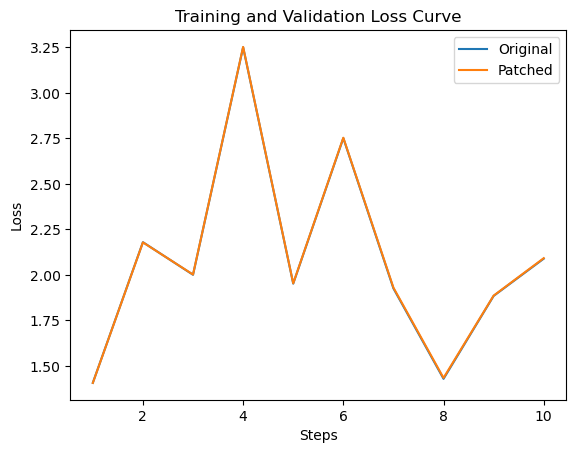

In [26]:
import matplotlib.pyplot as plt

train_history = trainer.state.log_history
fsdp2_losses = []
fsdp2_steps = []

for log in train_history:
    if "loss" in log:
        fsdp2_losses.append(log["loss"])
        fsdp2_steps.append(log["step"])
fsdp2_losses


plt.plot(original_steps, original_losses, label="Original")
plt.plot(fsdp2_steps, fsdp2_losses, label="Patched")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve")
plt.legend()  # Show the legend
plt.show()